In [13]:
from scipy.io import loadmat
import pandas as pd

# load matlab files
images_mat = loadmat("C:\\Users\\feder\\OneDrive\\Desktop\\Deep Learning\\Dataset_project\\ChallengeDB_release\\Data\\AllImages_release.mat")
mos_mat = loadmat("C:\\Users\\feder\\OneDrive\\Desktop\\Deep Learning\\Dataset_project\\ChallengeDB_release\\Data\\AllMOS_release.mat")
std_mat = loadmat("C:\\Users\\feder\\OneDrive\\Desktop\\Deep Learning\\Dataset_project\\ChallengeDB_release\\Data\\AllStdDev_release.mat")

# extract arrays
images = images_mat["AllImages_release"]
mos = mos_mat["AllMOS_release"]
std = std_mat["AllStdDev_release"]

# flatten data
image_names = [img[0] for img in images.flatten()]
mos_values = mos.flatten()
std_values = std.flatten()

# create dataframe
df = pd.DataFrame({
    "image": image_names,
    "mos": mos_values,
    "std": std_values
})

print(df[["mos", "std"]].describe())

               mos          std
count  1169.000000  1169.000000
mean     55.388736    19.249702
std      20.287140     2.899819
min       3.420000     6.755828
25%      43.118919    17.778260
50%      59.481283    19.492680
75%      71.681564    21.059473
max      92.431953    28.592859


Per quanto riguarda il MOS (Mean Opinion Score):
-   Il valore medio è circa pari a 55.39, mentre la mediana è circa 59.48.
-   La mediana maggiore della media suggerisce una distribuzione leggermente sbilanciata verso valori bassi (left-skewed),
    probabilmente dovuta alla presenza di alcune immagini percepite come molto degradate.
-   Il range è molto ampio: [3.42 - 92.43], indicando che il dataset copre immagini con qualità molto differenti, dalle peggiori alle migliori.
-   L’intervallo interquartile vale circa 28.56, che è piuttosto elevato. Questo suggerisce che il dataset possiede una buona variabilità
    percettiva, caratteristica molto importante per addestrare modelli di deep learning robusti nella stima della qualità delle immagini.
-   Inoltre, la deviazione standard del MOS è circa 20.28, è significativa rispetto al range totale del punteggio, confermando che il dataset non è concentrato attorno a una singola fascia di qualità, ma distribuito su diversi livelli percettivi.

Per quanto riguarda invece la Standard Deviation delle opinioni umane:
-   la media è circa 19.25.
-   la deviazione standard è relativamente bassa è circa 2.90, questo significa che il livello di disaccordo tra gli annotatori non varia
    enormemente tra le immagini del dataset.
-   Il range è [6.76 - 28.59], mostra la presenza di immagini molto consensuali (std bassa), e immagini più ambigue o soggettive (std alta).

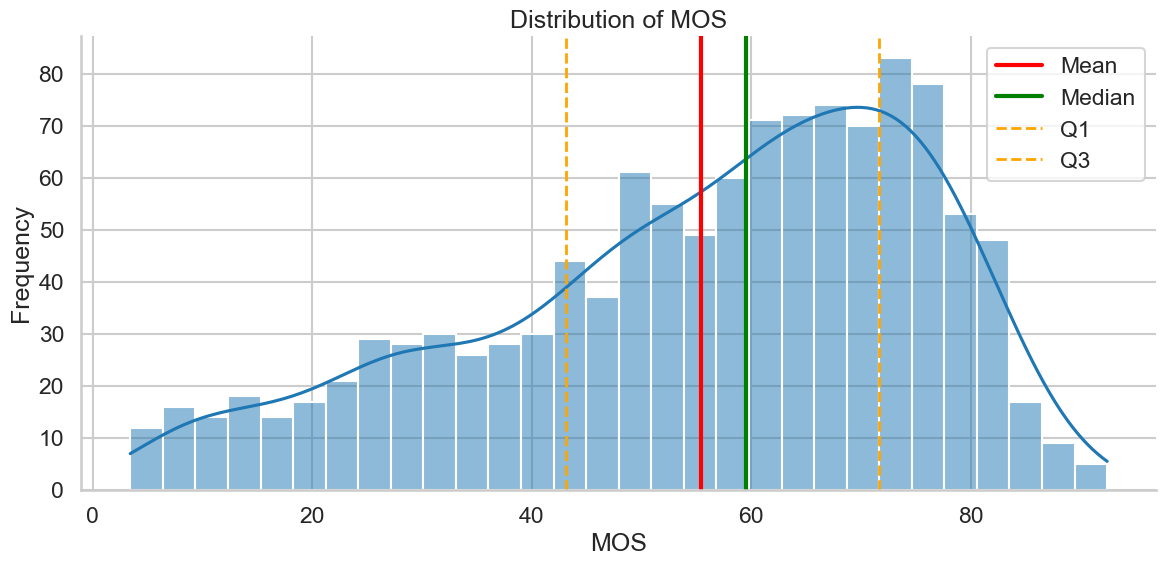

In [29]:
# HISTOGRAM MOS

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_context("talk")

mean_mos = df["mos"].mean()
median_mos = df["mos"].median()

q1_mos = df["mos"].quantile(0.25)
q3_mos = df["mos"].quantile(0.75)

plt.figure(figsize=(12,6))

sns.histplot(
    df["mos"],
    bins=30,
    kde=True
)

# Mean
plt.axvline(
    mean_mos,
    color="red",
    linewidth=3,
    label="Mean"
)

# Median
plt.axvline(
    median_mos,
    color="green",
    linewidth=3,
    label="Median"
)

# Q1
plt.axvline(
    q1_mos,
    color="orange",
    linestyle="--",
    linewidth=2,
    label="Q1"
)

# Q3
plt.axvline(
    q3_mos,
    color="orange",
    linestyle="--",
    linewidth=2,
    label="Q3"
)


plt.title("Distribution of MOS")
plt.xlabel("MOS")
plt.ylabel("Frequency")

plt.legend()

sns.despine()

plt.tight_layout()
plt.show()


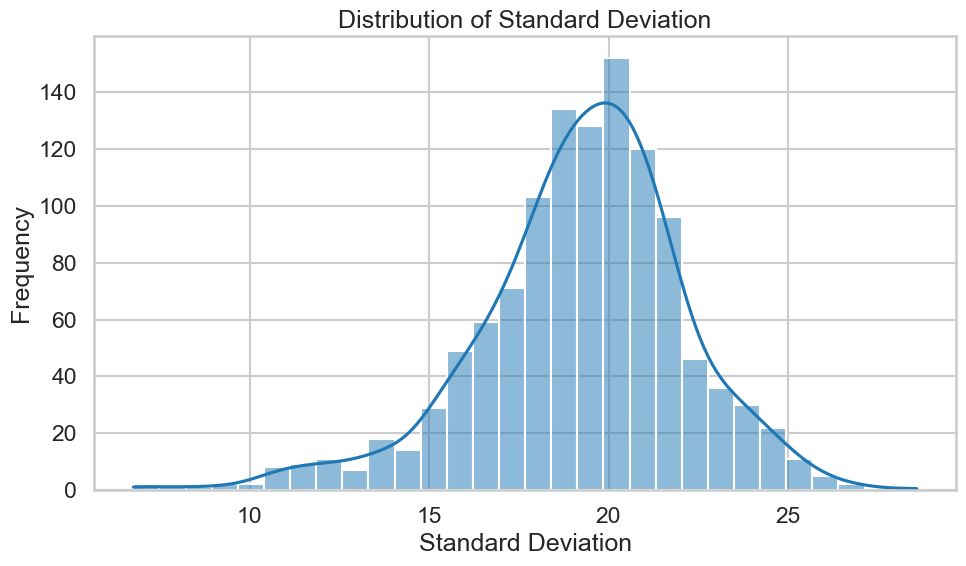

In [20]:
# HISTOGRAM STDDEV

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(10,6))

sns.histplot(
    df["std"],
    bins=30,
    kde=True
)

plt.title("Distribution of Standard Deviation")
plt.xlabel("Standard Deviation")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

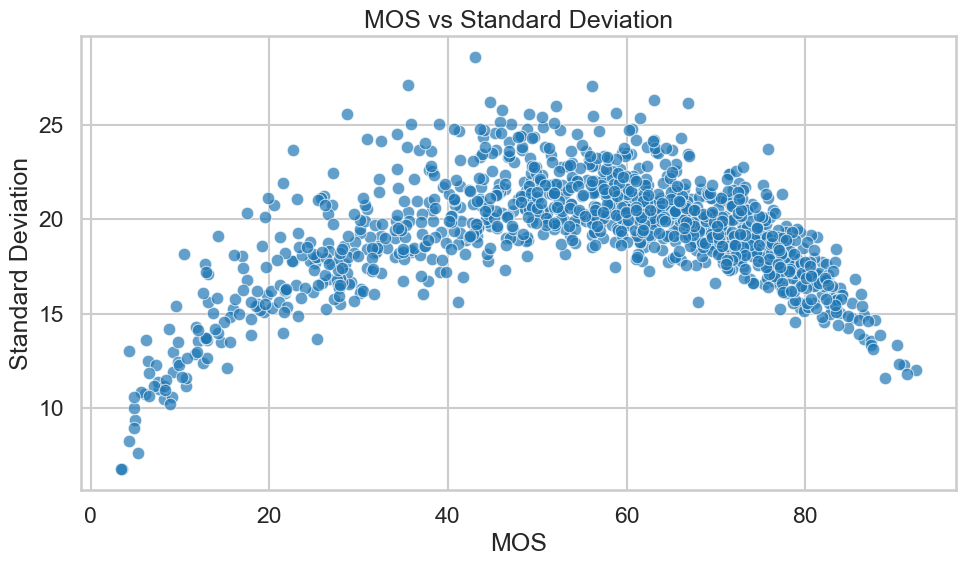

In [21]:
# SCATTERPLOT MOS vs STD

import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df["mos"],
    y=df["std"],
    alpha=0.7
)

plt.title("MOS vs Standard Deviation")
plt.xlabel("MOS")
plt.ylabel("Standard Deviation")

plt.tight_layout()
plt.show()

Il grafico scatterplot mostra la relazione tra il Mean Opinion Score (MOS) e la Standard Deviation delle valutazioni umane associate alle immagini del dataset. L’aspetto più interessante del grafico è la presenza di una chiara struttura non lineare, con andamento approssimativamente “a campana inversa”.

Si osserva infatti che:
-   per valori molto bassi di MOS , la deviazione standard tende a essere relativamente bassa.
-   per valori molto alti di MOS , la deviazione standard torna nuovamente a diminuire.
-   i valori più elevati di standard deviation si concentrano invece nella regione centrale del MOS, circa tra 40 e 70.

Il grafico suggerisce quindi che la variabilità delle opinioni non è costante rispetto al MOS, ma dipende fortemente dalla qualità percepita dell’immagine. In altre parole, il dataset presenta una forma di eteroschedasticità, dove la dispersione delle valutazioni cresce nelle regioni centrali del MOS e diminuisce agli estremi.
Un altro aspetto interessante è che il dataset appare molto denso nella regione centrale: MOS ≈ 50-75, indicando che molte immagini possiedono qualità medio-alta. Questo può suggerire un leggero sbilanciamento del dataset verso immagini percettivamente accettabili o realistiche, piuttosto che verso immagini estremamente degradate.